<a href="https://colab.research.google.com/github/krishna-2-005/SalesForecasting_KuchuruSaiKrishnaReddy/blob/main/Final_Project_Submission_XYLOFY_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Kuchuru Sai Krishna Reddy**

**Final Project Submission**

# Task 1: Data Loading, Feature Engineering and Exploratory Data Analysis

## Objective

The objective of this task is to understand the structure of the Superstore sales dataset, identify data quality issues, engineer time-based features, and perform exploratory data analysis to uncover business insights that will support forecasting and demand analysis in later stages of the project.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from datetime import datetime

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 9800
Columns : 18


### Observation

The dataset contains the complete Superstore sales records with multiple attributes describing customer details, product information, order information, geographical information, sales, profit, and shipping details. This dataset is suitable for performing exploratory analysis and time series forecasting.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### Observation

The dataset contains a combination of numerical, categorical, and date-related variables. The data types will be verified and date columns will be converted into datetime format before performing time series analysis.

In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
df.describe(include="object")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


### Observation

The statistical summary provides an overview of the numerical variables such as Sales, Quantity, Discount, and Profit. These statistics help identify the spread of the data, possible outliers, and the overall distribution of business metrics.

In [8]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


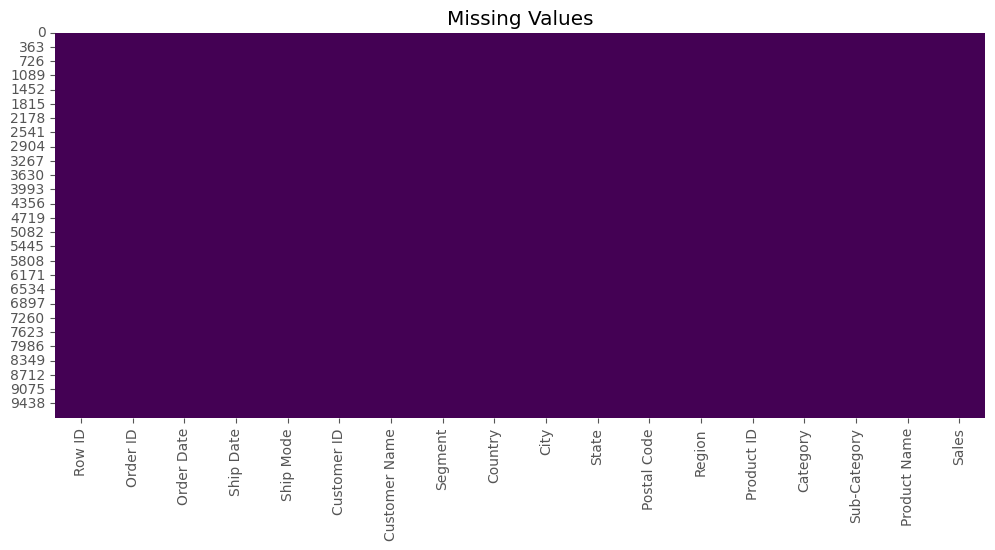

In [9]:
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.show()

### Observation

The dataset was examined for missing values to ensure data quality before analysis. Any missing observations will be handled appropriately if detected.

In [10]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


### Observation

Duplicate records were checked to prevent biased analysis and incorrect forecasting results.

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [12]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


## Feature Engineering

Time-based features were extracted from the `Order Date` column to support exploratory analysis and forecasting. These features help identify yearly trends, monthly seasonality, weekly patterns, and quarterly sales behavior.


In [13]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Order Date"].dt.day
df["Day Name"] = df["Order Date"].dt.day_name()
df["Day of Week"] = df["Order Date"].dt.dayofweek

In [14]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Day Name,Day of Week,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,8,Wednesday,2,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,8,Wednesday,2,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,12,Monday,0,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,11,Tuesday,1,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,11,Tuesday,1,Autumn


### Observation

The dataset now contains additional time-based variables including Year, Month, Quarter, Week, Day, Day Name, and Season. These engineered features will be used to analyze sales trends and will serve as important predictors for the forecasting models developed in later tasks.

## Weekly and Monthly Sales Aggregation

Sales data was aggregated into weekly and monthly intervals to support time series analysis and forecasting. Weekly aggregation is useful for anomaly detection, while monthly aggregation is used for forecasting models.

In [16]:
daily_sales = df.groupby("Order Date")["Sales"].sum()

weekly_sales = daily_sales.resample("W").sum()

monthly_sales = daily_sales.resample("ME").sum()

In [17]:
weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [18]:
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


### Observation

The sales data has been successfully aggregated into weekly and monthly time series. Weekly data will be used for anomaly detection, while monthly data provides a smoother trend suitable for forecasting models such as SARIMA, Prophet, and XGBoost.

In [19]:
weekly_sales_df = weekly_sales.reset_index()
monthly_sales_df = monthly_sales.reset_index()

In [20]:
print("Weekly Sales Shape :", weekly_sales_df.shape)
print("Monthly Sales Shape :", monthly_sales_df.shape)

Weekly Sales Shape : (209, 2)
Monthly Sales Shape : (48, 2)


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand the distribution of sales across different product categories, regions, customer segments, and time periods. The objective is to identify patterns, trends, and relationships that will support forecasting and business decision-making.

### Distribution of Sales

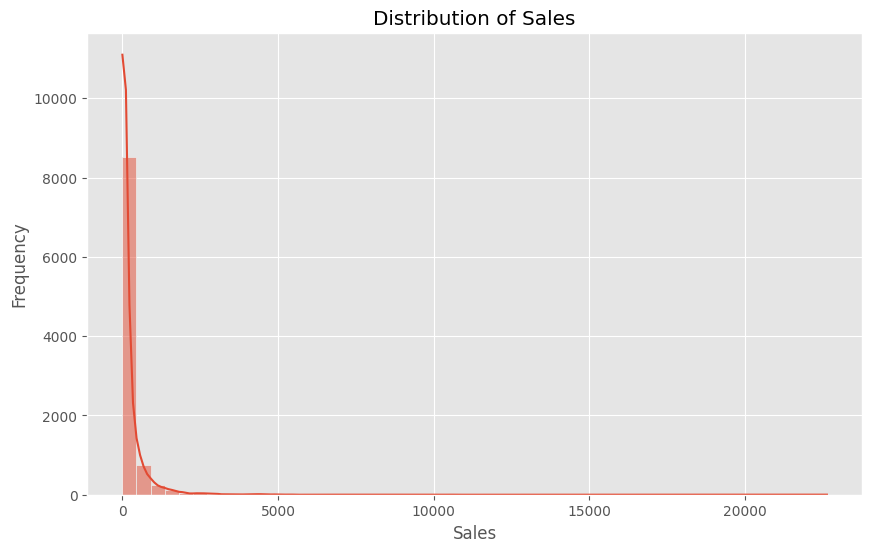

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(df["Sales"], bins=50, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

### Observation

The sales distribution is positively skewed, indicating that most transactions involve relatively small sales values while a few transactions contribute significantly higher sales. This pattern is common in retail datasets and suggests the presence of high-value orders.

### Sales Distribution by Category

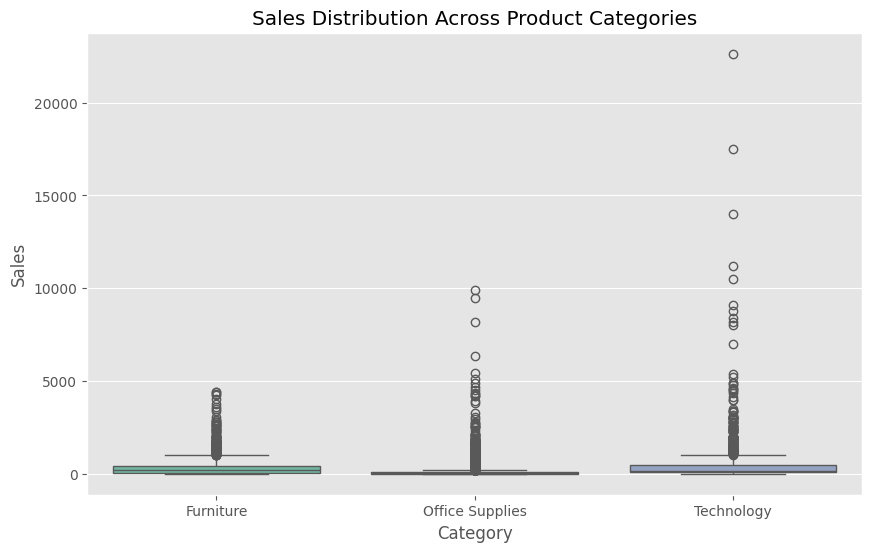

In [22]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="Category", y="Sales", palette="Set2")

plt.title("Sales Distribution Across Product Categories")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

### Observation

The box plot illustrates the distribution of sales across product categories. It highlights the variability of sales, median sales values, and potential outliers within each category. This analysis helps identify categories with consistently higher sales and those exhibiting greater variation in transaction values.

### Sales by Customer Segment

Customer segments were analyzed to determine which group contributes the highest share of total sales.

In [23]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

segment_sales

,Segment,Sales
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


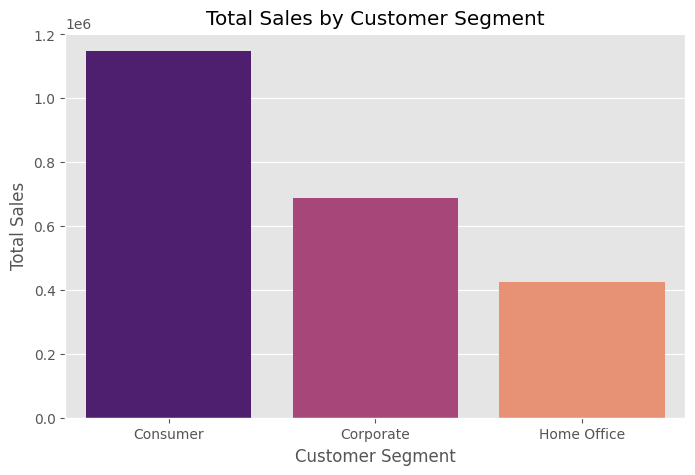

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_sales,
    x="Segment",
    y="Sales",
    palette="magma"
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.show()

### Observation

The comparison of customer segments highlights which customer group contributes the greatest proportion of sales. These insights can support targeted marketing strategies and customer relationship management.

### Monthly Sales Trend

Monthly sales were analyzed to understand long-term trends and seasonal variations over the four-year period.

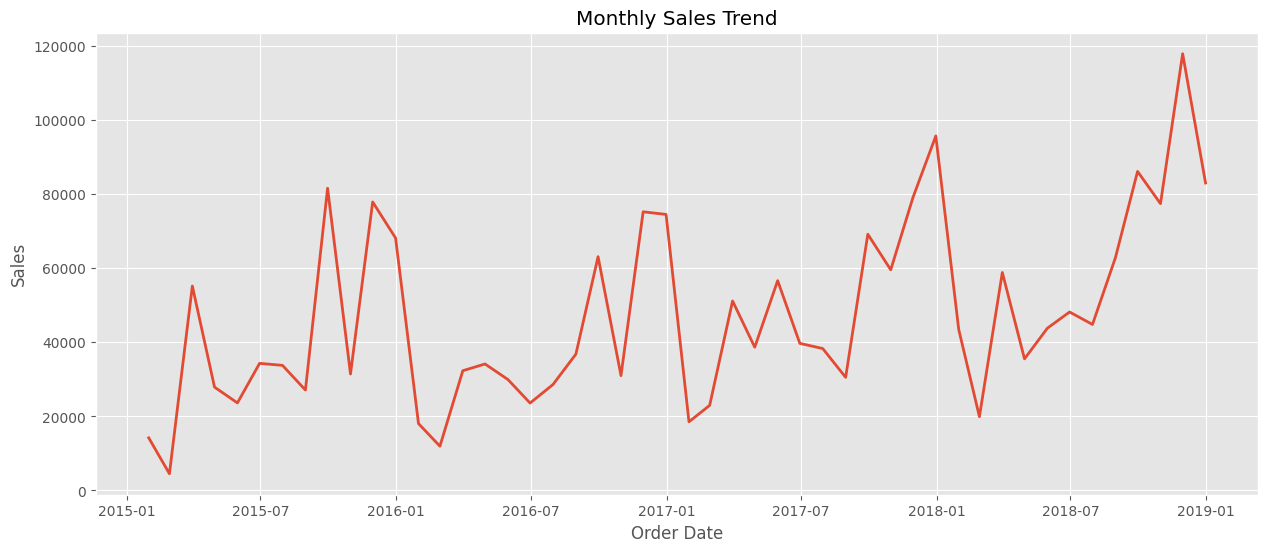

In [25]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observation

The monthly sales trend illustrates changes in sales over time and provides an initial understanding of growth patterns and seasonality. These patterns will be examined further during the time series decomposition stage.

### Weekly Sales Trend

Weekly sales were analyzed to capture short-term fluctuations that may not be visible in the monthly aggregation.

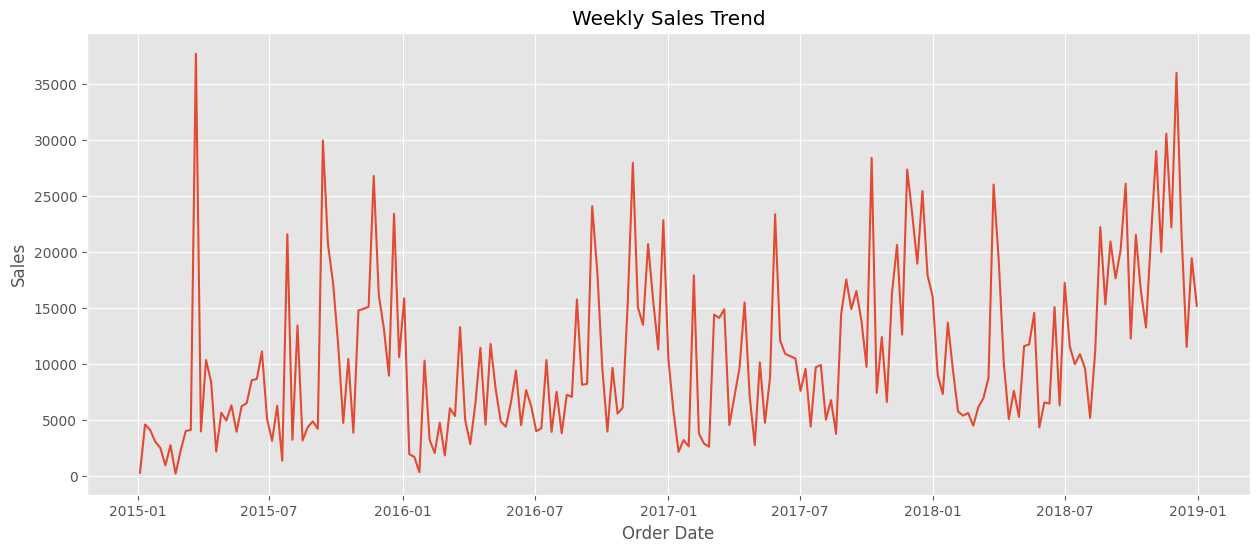

In [26]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales.values,
    linewidth=1.5
)

plt.title("Weekly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observation

Weekly sales exhibit greater variability than monthly sales, making them suitable for identifying unusual sales spikes and anomalies. This aggregated dataset will be used later for anomaly detection.

## Business Question 1: Which Product Category Generates the Highest Total Revenue?

The total sales generated by each product category were calculated to identify the highest revenue-contributing category. This analysis helps businesses prioritize inventory planning, marketing strategies, and future forecasting efforts.

In [27]:
category_revenue = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_revenue

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


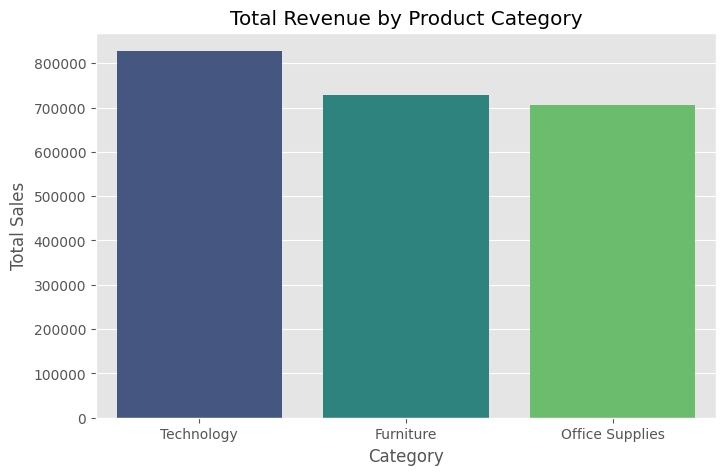

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_revenue,
    x="Category",
    y="Sales",
    hue="Category",
    palette="viridis",
    legend=False
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

### Observation

The Technology category generated the highest total revenue among all product categories, followed by Furniture and Office Supplies. This indicates that Technology products contribute the largest share of overall sales and play a significant role in the company's revenue. From a business perspective, maintaining adequate inventory levels and accurate demand forecasts for Technology products should be a priority to maximize sales opportunities and minimize stock shortages.

## Business Question 2: Which Region Has the Most Consistent Sales Growth?

To evaluate regional sales performance, monthly sales were aggregated for each region over the four-year period. Comparing these trends helps identify the region with the most stable and consistent sales growth, which is valuable for inventory planning and strategic business decisions.

In [29]:
region_monthly = (
    df.groupby(["Region", pd.Grouper(key="Order Date", freq="M")])["Sales"]
      .sum()
      .reset_index()
)

region_monthly.head()

,Region,Order Date,Sales
0,Central,2015-01-31,1533.966
1,Central,2015-02-28,1233.174
2,Central,2015-03-31,5827.602
3,Central,2015-04-30,3712.340
4,Central,2015-05-31,4044.522


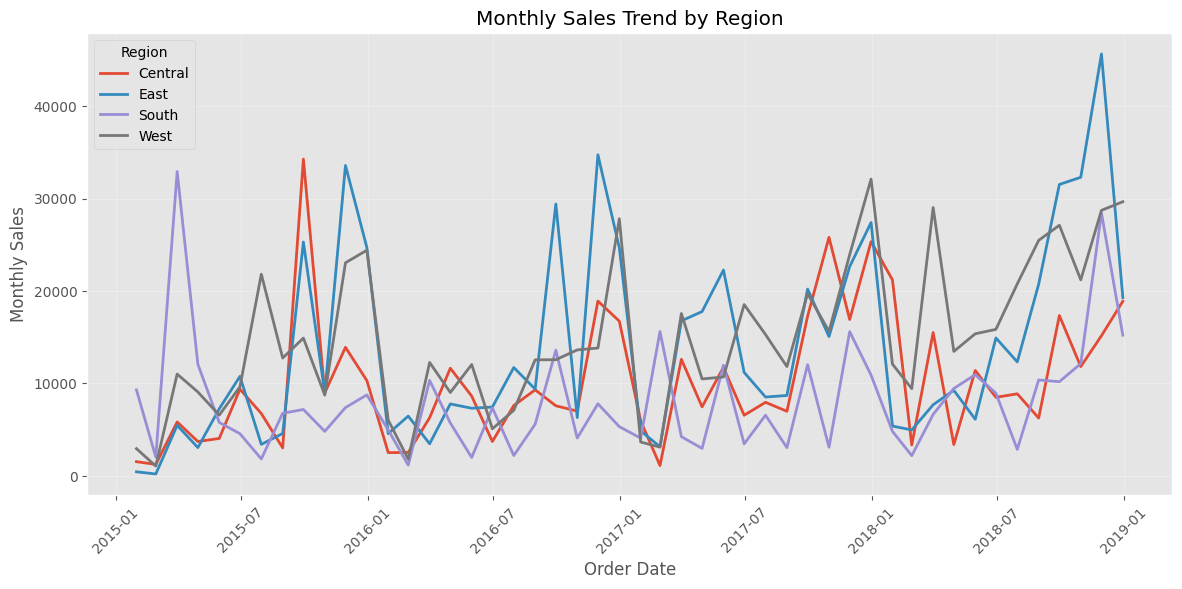

In [30]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=region_monthly,
    x="Order Date",
    y="Sales",
    hue="Region",
    linewidth=2
)

plt.title("Monthly Sales Trend by Region")
plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

### Observation

The West region demonstrates the most consistent sales growth over the four-year period, showing a relatively steady upward trend with fewer extreme fluctuations than the other regions. Although the East region records the highest sales peaks, its performance is more volatile. The stable growth observed in the West region makes it a reliable market for forecasting and long-term inventory planning.

## Business Question 3: What is the Average Shipping Time Between Order Date and Ship Date?

To evaluate delivery performance, the shipping duration was calculated by finding the difference between the shipping date and the order date for each transaction. The average shipping time was then compared across all regions.

In [31]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [32]:
shipping_time = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .round(2)
      .sort_values()
      .reset_index()
)

shipping_time

,Region,Shipping Days
0,East,3.91
1,West,3.93
2,South,3.96
3,Central,4.07


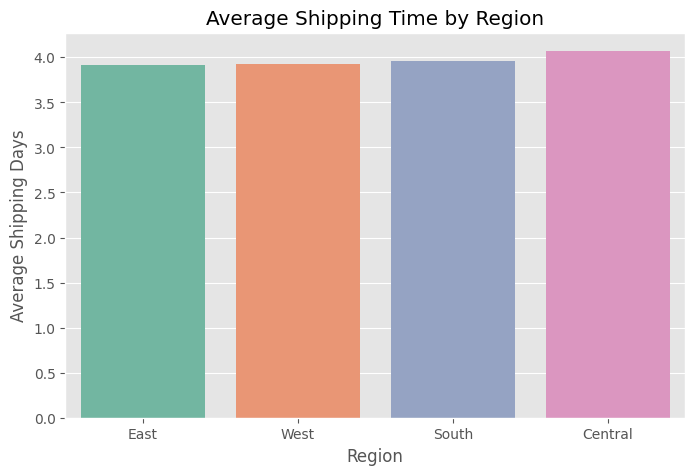

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=shipping_time,
    x="Region",
    y="Shipping Days",
    hue="Region",
    palette="Set2",
    legend=False
)

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.show()

### Observation

The average shipping time across all regions is approximately four days, indicating a generally consistent delivery process throughout the business. The East region has the shortest average shipping time, while the Central region has the longest. However, the differences between regions are minimal, suggesting that the company's logistics operations are fairly standardized across geographical locations.

## Business Question 4: Are There Months That Consistently Show Higher Sales Across All Years?

To identify seasonal demand patterns, the average sales for each month were calculated across the entire dataset. Understanding seasonality is essential for selecting appropriate forecasting models and planning inventory requirements.

In [34]:
monthly_pattern = (
    df.groupby("Month Name")["Sales"]
      .mean()
      .reindex([
          "January",
          "February",
          "March",
          "April",
          "May",
          "June",
          "July",
          "August",
          "September",
          "October",
          "November",
          "December"
      ])
      .reset_index()
)

monthly_pattern

,Month Name,Sales
0,January,257.627403
1,February,199.902745
2,March,290.549393
3,April,207.432269
4,May,212.533412
5,June,211.052856
6,July,208.802997
7,August,227.007110
8,September,221.642106
9,October,246.596162


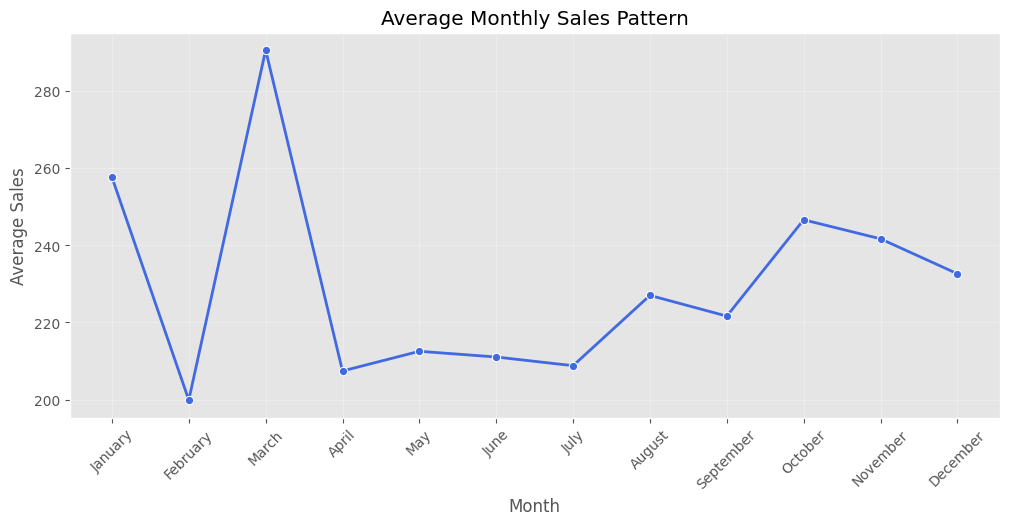

In [35]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_pattern,
    x="Month Name",
    y="Sales",
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.title("Average Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

### Observation

The average monthly sales pattern indicates clear seasonality in customer demand. Sales reach their highest level in March, followed by strong performance during October, November, and December. In contrast, February records the lowest average sales. These recurring monthly patterns suggest that seasonality plays an important role in sales performance and should be incorporated into forecasting models to improve prediction accuracy.

# Task 1 Conclusion

The dataset was successfully prepared for time series analysis through data preprocessing, feature engineering, and exploratory data analysis. Date variables were converted into an appropriate datetime format, and additional temporal features such as year, month, quarter, week, and season were extracted.

Sales data was aggregated into weekly and monthly intervals to support different analytical tasks. Exploratory analysis identified Technology as the highest revenue-generating product category, while the West region demonstrated relatively consistent sales growth over time. The average shipping time remained close to four days across all regions, indicating a standardized delivery process. Monthly sales analysis also revealed recurring seasonal patterns, with March and the final quarter of the year showing higher average sales.

These findings provide a strong foundation for the time series decomposition, forecasting, anomaly detection, and demand segmentation tasks that follow in the subsequent stages of the project.

# Task 2: Time Series Analysis and Decomposition

## Objective

The objective of this task is to analyze the temporal behaviour of sales over time, identify long-term trends and seasonal patterns, evaluate the stationarity of the time series, and prepare the data for forecasting models. Time series decomposition helps separate the observed sales into trend, seasonal, and residual components, providing a better understanding of the underlying data structure.

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [37]:
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [38]:
monthly_sales.tail()

,Sales
Order Date,
2018-08-31,62837.8480
2018-09-30,86152.8880
2018-10-31,77448.1312
2018-11-30,117938.1550
2018-12-31,83030.3888


## Monthly Sales Time Series

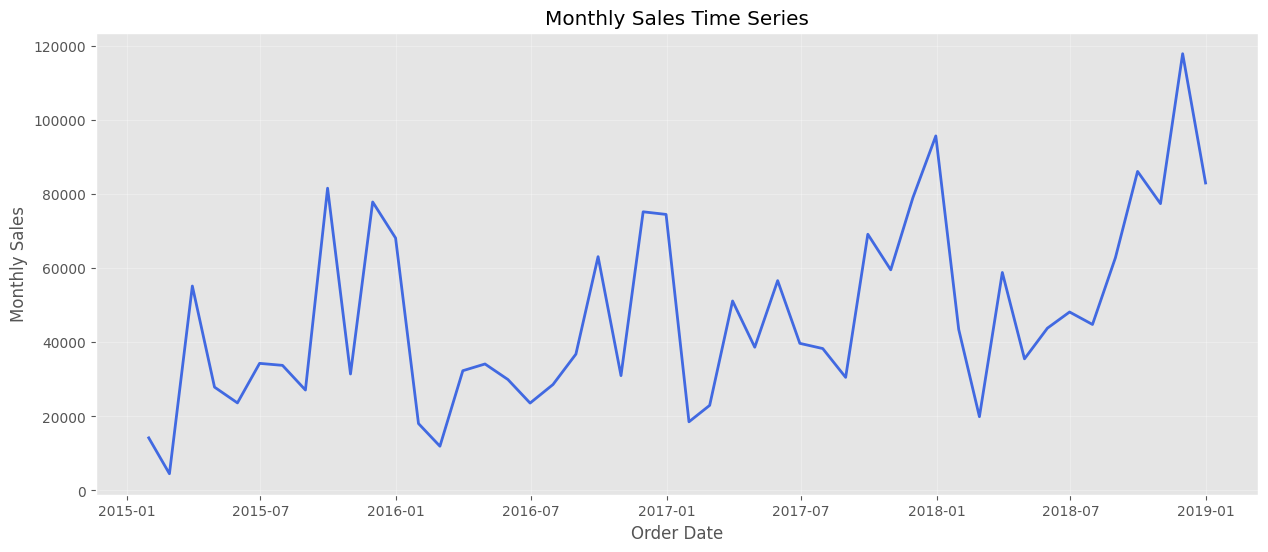

In [39]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    color="royalblue",
    linewidth=2
)

plt.title("Monthly Sales Time Series")
plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")

plt.grid(alpha=0.3)

plt.show()

### Observation

The monthly sales time series shows fluctuations throughout the four-year period along with an overall upward movement in sales. These fluctuations suggest the presence of both long-term trends and seasonal behaviour, making time series decomposition an appropriate next step.

## Time Series Decomposition

Time series decomposition separates the observed sales into three major components:

- Trend
- Seasonal
- Residual

This analysis helps distinguish long-term growth from recurring seasonal effects and random fluctuations.

In [40]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

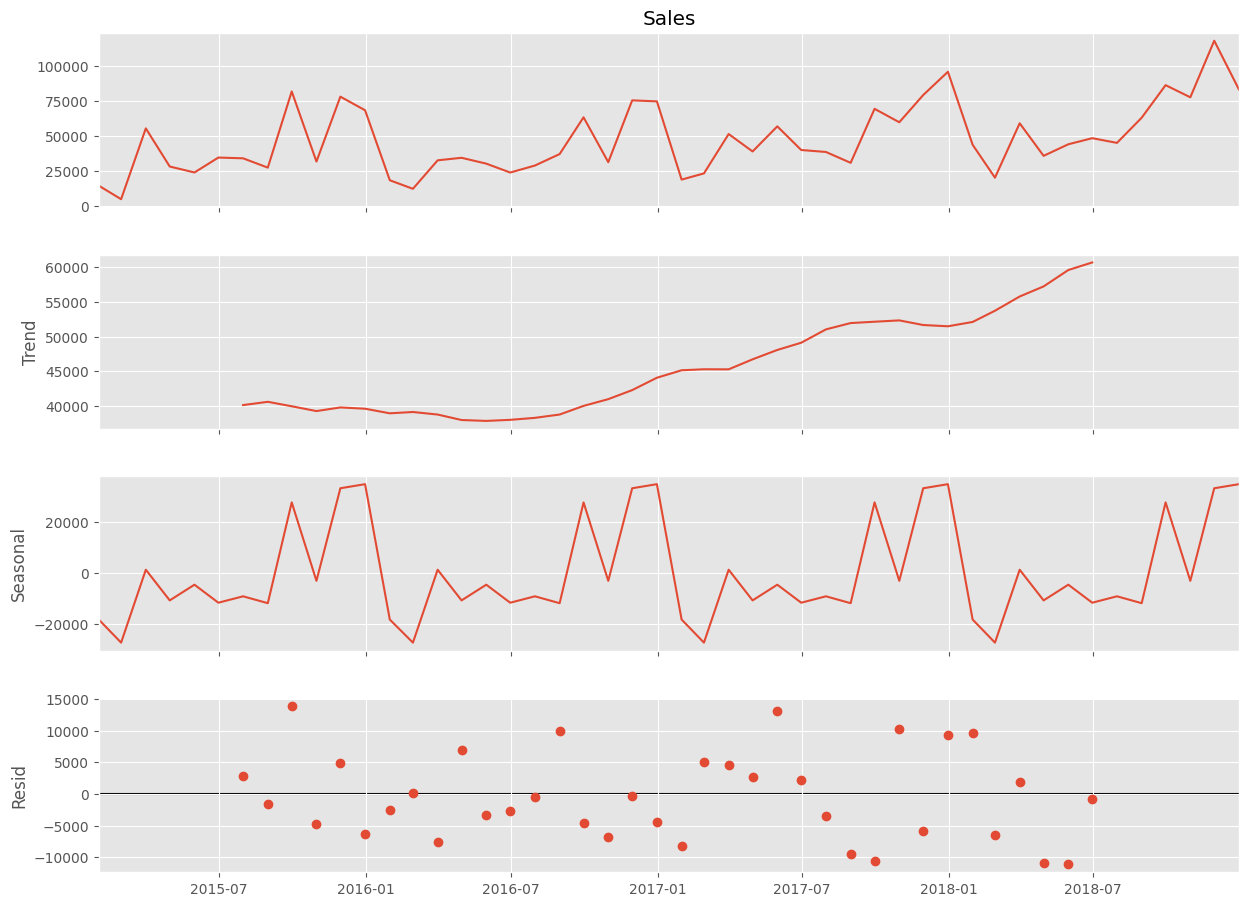

In [41]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

### Interpretation

The decomposition of the monthly sales time series reveals three distinct components: trend, seasonality, and residual variation. Separating these components provides a clearer understanding of the underlying sales behaviour and helps determine whether forecasting models should account for long-term growth and recurring seasonal patterns.

### Business Insight

The decomposition indicates that sales are influenced by both long-term business growth and recurring seasonal effects. This suggests that forecasting models capable of handling seasonality, such as SARIMA and Prophet, are appropriate choices for predicting future sales.

### Conclusion

The sales series contains meaningful trend and seasonal information rather than purely random fluctuations, making it suitable for advanced time series forecasting techniques.

## Trend Analysis

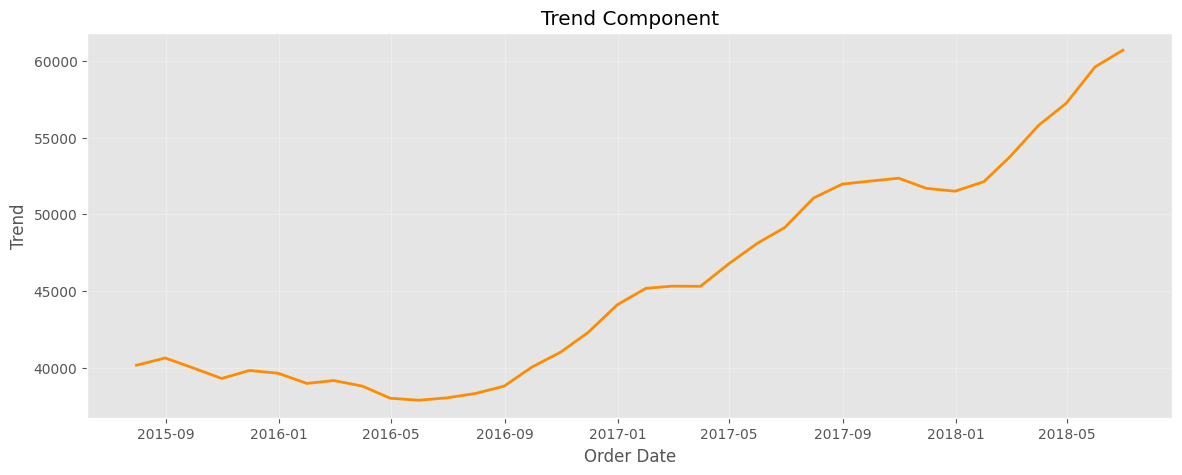

In [42]:
plt.figure(figsize=(14,5))

plt.plot(
    decomposition.trend,
    linewidth=2,
    color="darkorange"
)

plt.title("Trend Component")
plt.xlabel("Order Date")
plt.ylabel("Trend")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The trend component shows a gradual increase in monthly sales over the four-year period. After a relatively stable phase during 2015 and early 2016, sales begin to rise steadily from late 2016 onwards, reaching their highest levels in 2018.

### Business Insight

The upward trend indicates sustained business growth over time. Increasing customer demand suggests that inventory planning, procurement, and supply chain capacity should be adjusted to accommodate future sales growth.

### Conclusion

The presence of a clear upward trend confirms that the sales series is not stationary and should be transformed before applying statistical forecasting models such as SARIMA.

## Seasonal Component

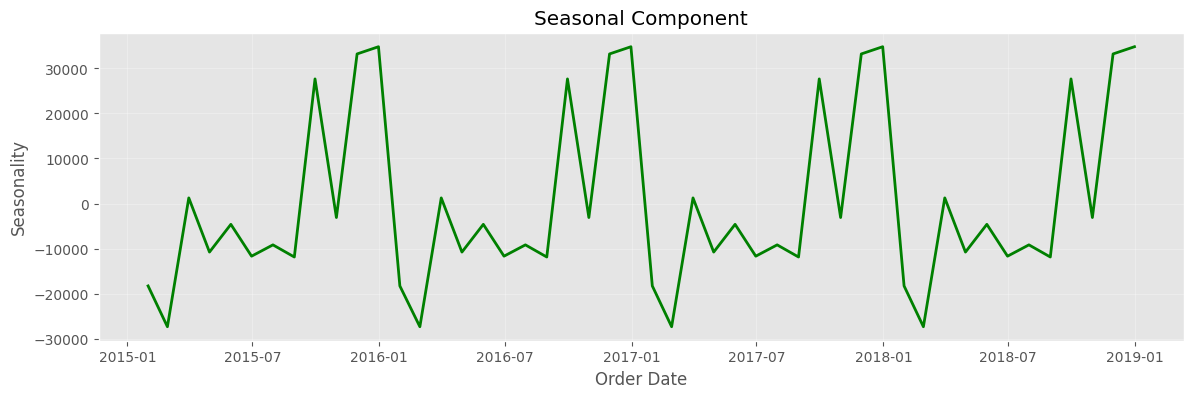

In [43]:
plt.figure(figsize=(14,4))

plt.plot(
    decomposition.seasonal,
    linewidth=2,
    color="green"
)

plt.title("Seasonal Component")
plt.xlabel("Order Date")
plt.ylabel("Seasonality")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The seasonal component displays recurring monthly fluctuations that repeat consistently throughout the observation period. Certain months contribute positively to overall sales, while others consistently experience lower sales.

### Business Insight

The recurring seasonal behaviour indicates predictable changes in customer demand throughout the year. Businesses can use these patterns to optimize inventory levels, promotional campaigns, and staffing during peak and low-demand periods.

### Conclusion

Seasonality is a significant characteristic of the sales data and should be incorporated into forecasting models to improve prediction accuracy.

## Residual Component

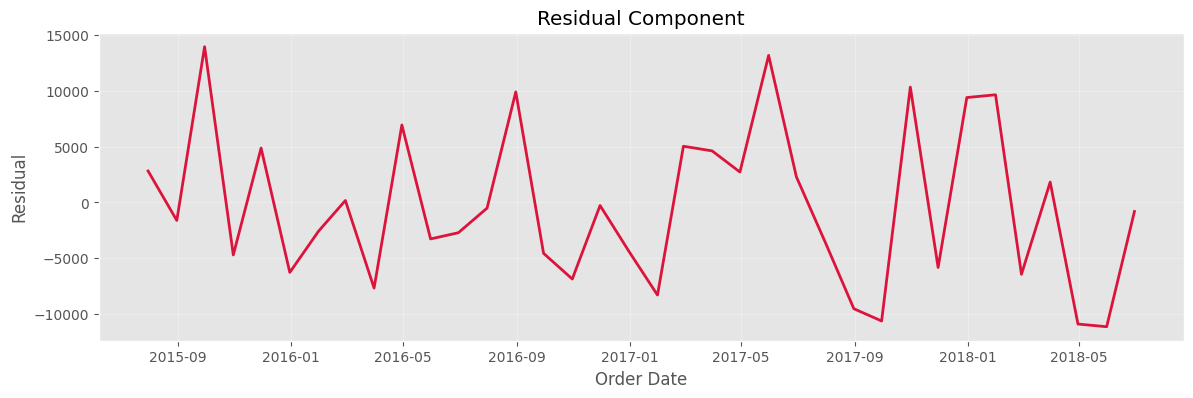

In [44]:
plt.figure(figsize=(14,4))

plt.plot(
    decomposition.resid,
    linewidth=2,
    color="crimson"
)

plt.title("Residual Component")
plt.xlabel("Order Date")
plt.ylabel("Residual")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The residual component represents random variations that remain after removing the trend and seasonal effects. Most residual values fluctuate around zero, although a few larger deviations indicate unexpected events that cannot be explained by trend or seasonality alone.

### Business Insight

These irregular fluctuations may result from special promotions, unexpected market conditions, or external business events. Monitoring these deviations can help identify anomalies and improve future forecasting performance.

### Conclusion

Most systematic variation has been successfully captured by the trend and seasonal components, leaving only a limited amount of unexplained random noise.

## Stationarity Test Using the Augmented Dickey-Fuller (ADF) Test

Before building forecasting models, it is important to determine whether the time series is stationary. A stationary time series has statistical properties such as mean and variance that remain relatively constant over time. Many statistical forecasting models, including SARIMA, assume that the input time series is stationary.

The Augmented Dickey-Fuller (ADF) test is used to evaluate stationarity.

- **Null Hypothesis (H₀):** The time series is non-stationary.
- **Alternative Hypothesis (H₁):** The time series is stationary.

If the p-value is less than 0.05, the null hypothesis is rejected, indicating that the series is stationary.

In [45]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales)

print("ADF Statistic :", adf_result[0])
print("P-value       :", adf_result[1])
print("No. of Lags   :", adf_result[2])
print("Observations  :", adf_result[3])

print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
P-value       : 0.00027791039276670623
No. of Lags   : 0
Observations  : 47

Critical Values
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


In [46]:
adf_summary = pd.DataFrame({
    "Metric": [
        "ADF Statistic",
        "P-value",
        "Number of Lags",
        "Observations"
    ],
    "Value": [
        adf_result[0],
        adf_result[1],
        adf_result[2],
        adf_result[3]
    ]
})

adf_summary

,Metric,Value
0,ADF Statistic,-4.416137
1,P-value,0.000278
2,Number of Lags,0.000000
3,Observations,47.000000


### Interpretation

The Augmented Dickey-Fuller (ADF) test was performed to evaluate whether the monthly sales time series is stationary. The test produced an ADF statistic of **-4.4161** and a **p-value of 0.000278**, which is significantly lower than the 0.05 significance level.

### Business Insight

Since the p-value is less than 0.05, the null hypothesis of non-stationarity is rejected. This indicates that the statistical properties of the monthly sales series remain relatively stable over time. A stationary series generally produces more reliable forecasting results because its underlying behaviour is more predictable.

### Conclusion

The monthly sales time series is stationary and is therefore suitable for statistical forecasting models. Based on the ADF test results, additional differencing is **not required** before proceeding with forecasting.

## Differencing

Differencing is commonly applied when a time series is non-stationary to stabilize its mean over time. However, the Augmented Dickey-Fuller (ADF) test indicates that the monthly sales series is already stationary (p-value < 0.05). Therefore, differencing is not required, and the original series will be used for forecasting.

# Task 2 Conclusion

Time series analysis revealed that the monthly sales data exhibits both long-term growth and recurring seasonal patterns. Seasonal decomposition successfully separated the observed sales into trend, seasonal, and residual components, providing valuable insights into the underlying structure of the data.

The Augmented Dickey-Fuller (ADF) test confirmed that the monthly sales series is stationary, eliminating the need for additional differencing before model development. These findings indicate that the dataset is well-prepared for implementing forecasting models such as SARIMA, Prophet, and XGBoost in the next stage of the project.